# 01_shooting_location_year — 年別進捗ダッシュボード版

スキャン写真を1枚ずつ確認し、撮影場所・撮影年/年代を判定して整理します。

## 未処理写真のフォルダ構成

撮影年が分かっている写真は、`unidentified/` の下に年フォルダを作成して配置します。

```text
unidentified/
├─ 1970/
│   ├─ IMG_001.jpg
│   └─ IMG_002.jpg
├─ 1971/
│   └─ IMG_003.jpg
├─ 1972/
│   └─ IMG_004.jpg
└─ UNKNOWN/
    └─ IMG_005.jpg
```

同じネガ・ポジ写真のまとまりを同じ年フォルダに入れておくことで、`.ipynb` 実行時に撮影年を自動入力します。

- `1970`, `1971`, `1972` …：撮影年が分かっている写真
- `UNKNOWN`：撮影年が分からない写真

## 年別進捗ダッシュボード

Notebookの上部に、年フォルダごとの

- 処理済み枚数
- 未処理枚数
- 合計枚数
- 進捗率
- 全体進捗

を表示します。

進捗情報は `data/processing_progress.json` に保存します。これにより、Notebookを閉じたり再起動したりしても、これまでの処理枚数を維持できます。

※「処理済み」は、A：`photo/` へ保存、または B：市区町村フォルダへ移動した写真を指します。C：スキップした写真は未処理として残ります。

## 処理ルール

A：緯度経度を地図クリックで指定 → `photo/` に保存  
B：市区町村のみ特定 → 元の年フォルダの下に市区町村フォルダを作成  
C：特定不能 → 現在の年フォルダに残して次へ


In [1]:
%pip install -q ipywidgets ipyleaflet pillow

Note: you may need to restart the kernel to use updated packages.


Output()

HTML(value='<h3>写真 1 / 205 <code>img196.jpg</code></h3>')

HTML(value='<b>元フォルダ：</b><code>1981</code>')

HTML(value='<b>元フォルダの撮影年：</b>1981年')

HTML(value='')

Text(value='img196', description='タイトル:', layout=Layout(width='500px'))

Textarea(value='', description='説明:', layout=Layout(height='80px', width='700px'))

Text(value='', description='市区町村:', layout=Layout(width='350px'), placeholder='例：港区')

HTML(value='<hr>')

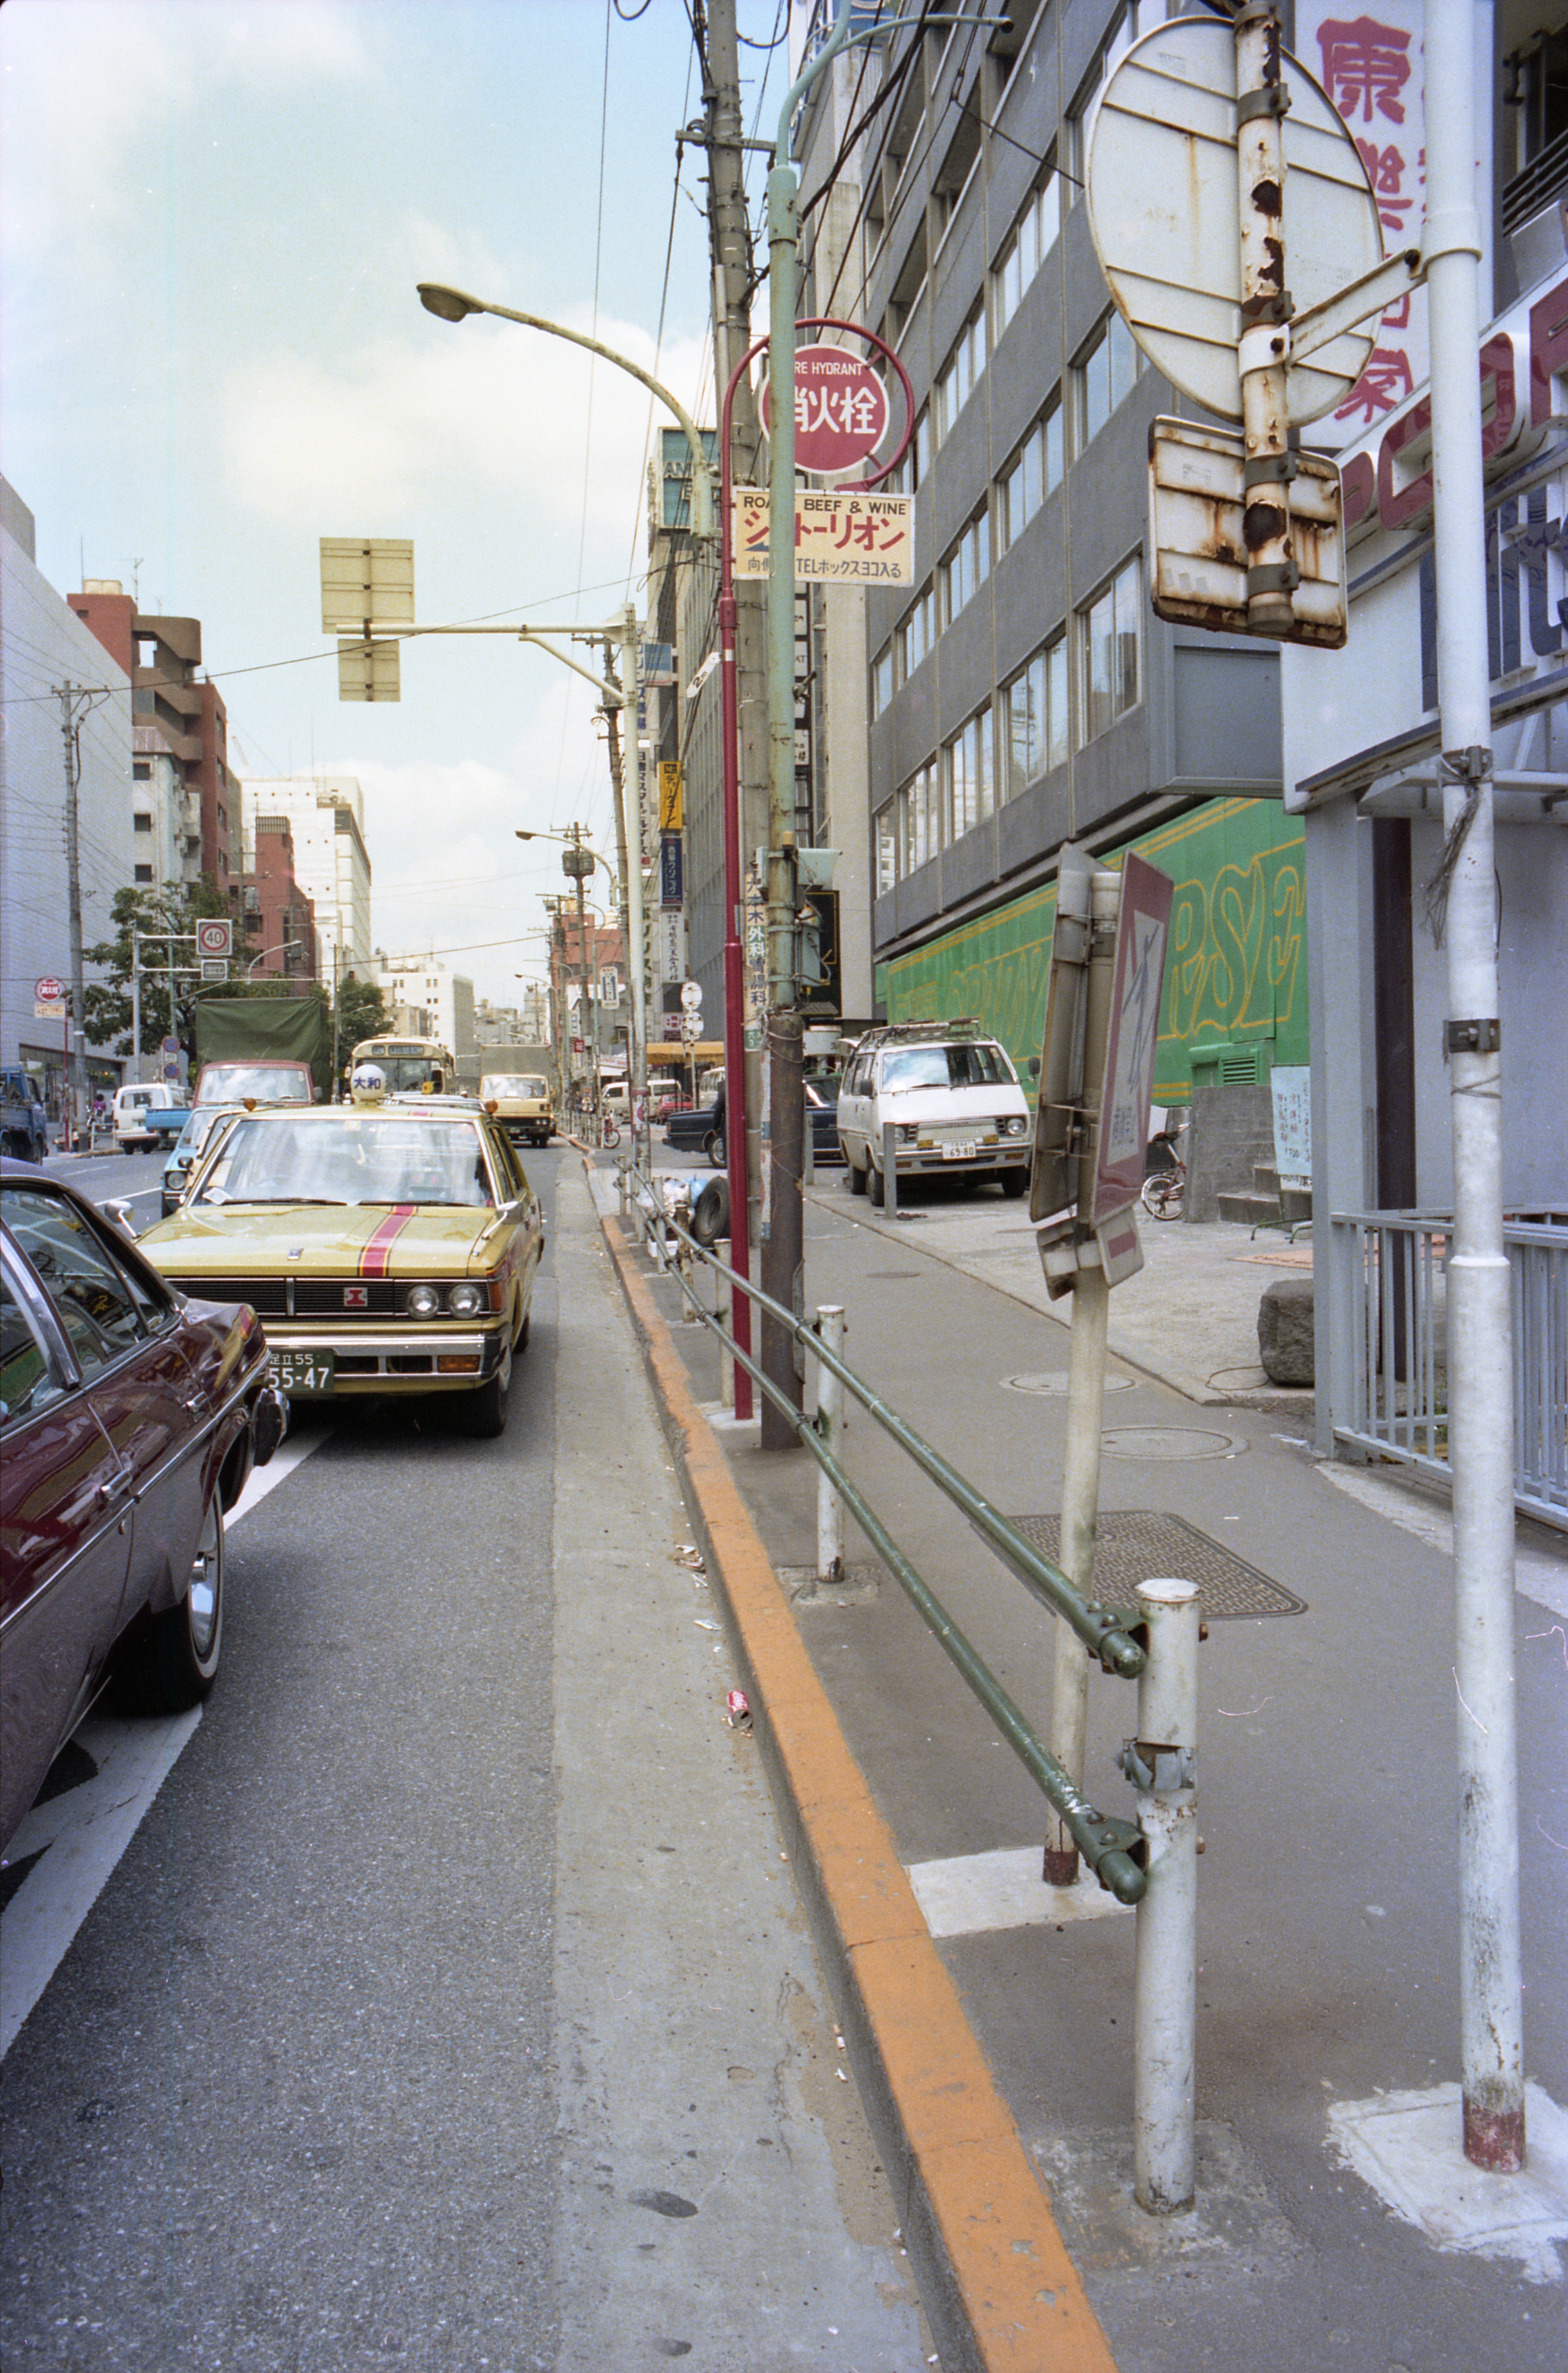

HTML(value='<h4>撮影場所：地図をクリックしてください</h4>')

Map(center=[35.681236, 139.767125], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

HTML(value='<b>選択地点：</b>未選択')

In [2]:
from pathlib import Path
import json
import shutil
import re
from datetime import datetime, timezone
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPImage
from ipyleaflet import Map, Marker

# ============================================================
# 設定
# ============================================================
CWD = Path.cwd()

# Notebookを _python/ から実行した場合は、1つ上をWebプロジェクトのルートとする
PROJECT_DIR = CWD.parent if CWD.name == "_python" else CWD
PY_DIR = PROJECT_DIR / "_python"

# 未処理写真
UNIDENTIFIED_DIR = PY_DIR / "unidentified"

# Webサイト用の処理済み写真
PHOTO_DIR = PROJECT_DIR / "photo"

# Webサイト用データ
DATA_DIR = PROJECT_DIR / "data"
CATALOG = DATA_DIR / "photos.json"
PROGRESS_FILE = DATA_DIR / "processing_progress.json"

for d in [PHOTO_DIR, UNIDENTIFIED_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 年が分からない写真を入れるフォルダ
UNKNOWN_DIR = UNIDENTIFIED_DIR / "UNKNOWN"
UNKNOWN_DIR.mkdir(exist_ok=True)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".tif", ".tiff", ".webp"
}

# 年の入力候補
YEAR_OPTIONS = ["不明"] + [str(y) for y in range(1850, 2031)]

# 年代の入力候補
DECADE_OPTIONS = ["不明"] + [
    f"{y}-{y+9}" for y in range(1850, 2030, 10)
]

queue = []
current_index = 0
current_photo = None

selected_lat = None
selected_lon = None

map_widget = None
marker = None


# ============================================================
# photos.json（Webサイト連携）
# ============================================================
def load_catalog():
    if not CATALOG.exists():
        return {"updated_at": None, "photos": []}
    try:
        return json.loads(CATALOG.read_text(encoding="utf-8"))
    except Exception:
        return {"updated_at": None, "photos": []}


def save_catalog(catalog):
    catalog["updated_at"] = datetime.now(timezone.utc).isoformat()
    tmp = CATALOG.with_suffix(".tmp")
    tmp.write_text(
        json.dumps(catalog, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )
    tmp.replace(CATALOG)


def make_id(lat, lon, year_label, filename):
    raw = f"{lat:.6f}_{lon:.6f}_{year_label}_{filename}"
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", raw)


def add_record(record):
    catalog = load_catalog()
    rows = catalog.get("photos", [])

    for i, photo in enumerate(rows):
        if photo.get("id") == record["id"]:
            rows[i] = record
            break
    else:
        rows.append(record)

    rows.sort(key=lambda p: (p.get("year_sort", 9999), p.get("title", "")))
    catalog["photos"] = rows
    save_catalog(catalog)


# ============================================================
# 進捗管理
# ============================================================
def load_progress():
    """保存済みの年別進捗を読み込む。"""
    if not PROGRESS_FILE.exists():
        return {}

    try:
        with open(PROGRESS_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict):
            return data

    except Exception as e:
        print(f"進捗ファイルの読み込みに失敗しました：{e}")

    return {}


def save_progress():
    """年別進捗をJSONに保存する。"""
    with open(PROGRESS_FILE, "w", encoding="utf-8") as f:
        json.dump(progress_data, f, ensure_ascii=False, indent=2)


def get_year_key_from_name(name):
    """フォルダ名から進捗管理用のキーを取得する。"""
    if name == "UNKNOWN":
        return "UNKNOWN"

    if re.fullmatch(r"\d{4}", name):
        year = int(name)
        if 1850 <= year <= 2030:
            return name

    return None


def get_year_dirs():
    """unidentified/直下の年フォルダとUNKNOWNを取得する。"""
    dirs = []

    if not UNIDENTIFIED_DIR.exists():
        return dirs

    for folder in UNIDENTIFIED_DIR.iterdir():
        if not folder.is_dir():
            continue

        key = get_year_key_from_name(folder.name)
        if key is not None:
            dirs.append((key, folder))

    def sort_key(item):
        key = item[0]
        if key == "UNKNOWN":
            return (1, 9999)
        return (0, int(key))

    return sorted(dirs, key=sort_key)


def count_direct_images(folder):
    """年フォルダ直下の画像枚数を数える。サブフォルダは除外。"""
    if not folder.exists():
        return 0

    return sum(
        1
        for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def refresh_progress_data():
    """
    現在のフォルダ内枚数を見て進捗情報を更新する。

    total = 過去に確認した総枚数と、
            processed + 現在フォルダに残っている枚数の大きい方。
    これにより、後から同じ年フォルダに写真を追加しても反映される。
    """
    changed = False

    for key, folder in get_year_dirs():
        remaining = count_direct_images(folder)
        record = progress_data.setdefault(
            key,
            {"total": 0, "processed": 0}
        )

        old_total = int(record.get("total", 0))
        processed = int(record.get("processed", 0))
        new_total = max(old_total, processed + remaining)

        if record.get("total") != new_total:
            record["total"] = new_total
            changed = True

        if record.get("processed") != processed:
            record["processed"] = processed
            changed = True

    if changed:
        save_progress()


def register_processed(year_key):
    """A/Bで写真を処理したときに、その年の処理済み枚数を1増やす。"""
    if year_key is None:
        year_key = "UNKNOWN"

    record = progress_data.setdefault(
        year_key,
        {"total": 0, "processed": 0}
    )

    record["processed"] = int(record.get("processed", 0)) + 1

    # totalが不足していた場合にも整合性を保つ
    remaining = count_direct_images(UNIDENTIFIED_DIR / year_key)
    record["total"] = max(
        int(record.get("total", 0)),
        int(record["processed"]) + remaining
    )

    save_progress()


def progress_values():
    """ダッシュボード表示用の年別データを返す。"""
    refresh_progress_data()

    rows = []

    for key, folder in get_year_dirs():
        record = progress_data.get(key, {"total": 0, "processed": 0})
        processed = int(record.get("processed", 0))
        total = int(record.get("total", 0))
        remaining = count_direct_images(folder)

        # 現在フォルダに残る写真数を未処理枚数として表示
        # （市区町村サブフォルダへ移動した写真は処理済み）
        remaining = max(0, remaining)

        # 念のため、実ファイル数との整合を取る
        if total < processed + remaining:
            total = processed + remaining
            progress_data[key]["total"] = total
            save_progress()

        percent = (processed / total * 100) if total else 0

        rows.append({
            "key": key,
            "processed": processed,
            "remaining": remaining,
            "total": total,
            "percent": percent,
        })

    return rows


# 進捗データを読み込み
progress_data = load_progress()


# ============================================================
# ユーティリティ
# ============================================================
def get_source_year(photo):
    """
    写真が入っている年フォルダ名から撮影年を取得する。

    例：
        unidentified/1970/IMG_001.jpg → "1970"
        unidentified/UNKNOWN/IMG_002.jpg → None
    """
    try:
        parent_name = photo.parent.name

        if re.fullmatch(r"\d{4}", parent_name):
            year = int(parent_name)
            if 1850 <= year <= 2030:
                return str(year)

    except Exception:
        pass

    return None


def get_source_year_key(photo):
    """写真が現在入っている年フォルダ/UNKNOWNのキーを返す。"""
    key = get_year_key_from_name(photo.parent.name)
    return key if key is not None else "UNKNOWN"


def get_photos():
    """
    unidentified/直下の「年フォルダ」「UNKNOWN」だけを対象に、
    そのフォルダ直下にある画像を未処理写真として取得する。

    市区町村フォルダなど、その下のサブフォルダは対象外。
    """
    photos = []

    for year_key, year_dir in get_year_dirs():
        for photo in year_dir.iterdir():
            if (
                photo.is_file()
                and photo.suffix.lower() in IMAGE_EXTENSIONS
            ):
                photos.append(photo)

    return sorted(
        photos,
        key=lambda p: (
            (1, 9999) if p.parent.name == "UNKNOWN" else (0, int(p.parent.name)),
            p.name.lower()
        )
    )


def safe_name(name):
    """フォルダ名・ファイル名に使えない文字を置換する。"""
    name = name.strip()
    return re.sub(r'[\\/:*?"<>|]', "_", name)


def unique_destination(path):
    """同名ファイルがある場合は _001, _002 ... を付ける。"""
    if not path.exists():
        return path

    for i in range(1, 10000):
        candidate = path.with_name(
            f"{path.stem}_{i:03d}{path.suffix}"
        )
        if not candidate.exists():
            return candidate

    raise RuntimeError("同名ファイルが多すぎます。")


def set_status(text, kind="normal"):
    colors = {
        "normal": "#333333",
        "success": "#2e7d32",
        "warning": "#e65100",
        "error": "#c62828",
    }

    status.value = (
        f'<div style="font-size:15px;font-weight:bold;'
        f'color:{colors.get(kind, "#333333")}">'
        f'{text}'
        f'</div>'
    )


# ============================================================
# 年別進捗ダッシュボード
# ============================================================
def make_dashboard():
    """年別進捗と全体進捗をHTMLとして生成する。"""
    rows = progress_values()

    total_processed = sum(r["processed"] for r in rows)
    total_remaining = sum(r["remaining"] for r in rows)
    total_total = sum(r["total"] for r in rows)
    overall_percent = (
        total_processed / total_total * 100
        if total_total else 0
    )

    html = []
    html.append(
        '<div style="font-family:Arial,sans-serif;'
        'border:1px solid #ddd;border-radius:10px;'
        'padding:14px 16px;margin-bottom:14px;'
        'background:#fafafa;">'
    )

    html.append(
        '<div style="font-size:18px;font-weight:bold;margin-bottom:10px;">'
        '📊 年別進捗ダッシュボード'
        '</div>'
    )

    for r in rows:
        label = "年不明" if r["key"] == "UNKNOWN" else f'{r["key"]}年'
        pct = r["percent"]

        html.append(
            '<div style="display:flex;align-items:center;gap:8px;'
            'margin:6px 0;">'
        )
        html.append(
            f'<div style="width:75px;font-weight:bold;">{label}</div>'
        )
        html.append(
            '<div style="flex:1;background:#e9e9e9;'
            'height:16px;border-radius:8px;overflow:hidden;">'
            f'<div style="width:{min(pct,100):.1f}%;'
            'height:16px;background:#6c9bd2;">'
            '</div></div>'
        )
        html.append(
            f'<div style="width:155px;text-align:right;white-space:nowrap;">'
            f'{r["processed"]} / {r["total"]} 枚 '
            f'({pct:.0f}%)'
            f'</div>'
        )
        html.append('</div>')

    html.append(
        '<hr style="border:0;border-top:1px solid #ddd;margin:12px 0;">'
    )

    html.append(
        f'<div style="font-weight:bold;">'
        f'全体：{total_processed} / {total_total} 枚 '
        f'（{overall_percent:.0f}%）'
        f'</div>'
    )
    html.append(
        f'<div style="font-size:13px;color:#666;margin-top:4px;">'
        f'現在の未処理：{total_remaining}枚'
        f'</div>'
    )

    html.append('</div>')

    return widgets.HTML("".join(html))


# ============================================================
# UI
# ============================================================
status = widgets.HTML()

dashboard_output = widgets.Output()

coord_label = widgets.HTML(
    "<b>選択地点：</b>未選択"
)

source_year_label = widgets.HTML(
    "<b>元フォルダの撮影年：</b>不明"
)

mode = widgets.ToggleButtons(
    options=[
        ("特定年", "year"),
        ("撮影年代", "decade")
    ],
    value="year",
    description="指定方法:"
)

year_dropdown = widgets.Dropdown(
    options=YEAR_OPTIONS,
    value="不明",
    description="撮影年:",
    layout=widgets.Layout(width="220px")
)

decade_dropdown = widgets.Dropdown(
    options=DECADE_OPTIONS,
    value="不明",
    description="撮影年代:",
    layout=widgets.Layout(width="240px")
)

municipality = widgets.Text(
    description="市区町村:",
    placeholder="例：港区",
    layout=widgets.Layout(width="350px")
)

title = widgets.Text(
    description="タイトル:",
    layout=widgets.Layout(width="500px")
)

description = widgets.Textarea(
    description="説明:",
    layout=widgets.Layout(width="700px", height="80px")
)

save_btn = widgets.Button(
    description="A：緯度経度＋年/年代を保存",
    button_style="success",
    icon="save"
)

municipality_btn = widgets.Button(
    description="B：市区町村へ移動",
    button_style="info",
    icon="folder"
)

skip_btn = widgets.Button(
    description="C：スキップ",
    button_style="warning",
    icon="forward"
)

restart_btn = widgets.Button(
    description="最初から再読込",
    icon="refresh"
)


def update_dashboard():
    """ダッシュボードを現在の状態に更新する。"""
    with dashboard_output:
        clear_output(wait=True)
        display(make_dashboard())


# ============================================================
# 地図クリック
# ============================================================
def on_map_interaction(**kwargs):

    global selected_lat
    global selected_lon
    global marker

    if kwargs.get("type") != "click":
        return

    coords = kwargs.get("coordinates")
    if not coords:
        return

    selected_lat = float(coords[0])
    selected_lon = float(coords[1])

    coord_label.value = (
        f"<b>選択地点：</b>"
        f"lat={selected_lat:.6f}, "
        f"lon={selected_lon:.6f}"
    )

    if marker is not None:
        try:
            map_widget.remove_layer(marker)
        except Exception:
            pass

    marker = Marker(location=(selected_lat, selected_lon))
    map_widget.add_layer(marker)


def make_map():

    global map_widget
    global marker

    marker = None

    map_widget = Map(
        center=(35.681236, 139.767125),
        zoom=10,
        scroll_wheel_zoom=True
    )

    map_widget.on_interaction(on_map_interaction)

    return map_widget


# ============================================================
# 写真表示
# ============================================================
def show_photo():

    global current_photo
    global selected_lat
    global selected_lon

    # 写真キューを最新状態に更新
    if current_index >= len(queue):
        clear_output(wait=True)
        update_dashboard()
        display(dashboard_output)
        display(
            widgets.HTML(
                "<h2 style='color:#2e7d32'>処理完了</h2>"
                "<p>今回の処理キューに未処理写真はありません。</p>"
            )
        )
        display(restart_btn)
        return

    current_photo = queue[current_index]

    selected_lat = None
    selected_lon = None

    source_year = get_source_year(current_photo)

    if source_year is not None:
        year_dropdown.value = source_year
        source_year_label.value = (
            f"<b>元フォルダの撮影年：</b>{source_year}年"
        )
    else:
        year_dropdown.value = "不明"
        source_year_label.value = (
            "<b>元フォルダの撮影年：</b>"
            "UNKNOWN（年不明）"
        )

    decade_dropdown.value = "不明"
    municipality.value = ""
    title.value = current_photo.stem
    description.value = ""
    coord_label.value = "<b>選択地点：</b>未選択"

    clear_output(wait=True)

    update_dashboard()
    display(dashboard_output)

    display(
        widgets.HTML(
            f"<h3>写真 {current_index + 1} / {len(queue)} "
            f"<code>{current_photo.name}</code></h3>"
        )
    )

    display(
        widgets.HTML(
            f"<b>元フォルダ：</b><code>{current_photo.parent.name}</code>"
        )
    )

    display(source_year_label)
    display(status)

    display(widgets.HBox([mode, year_dropdown, decade_dropdown]))
    display(title)
    display(description)
    display(municipality)
    display(widgets.HBox([save_btn, municipality_btn, skip_btn]))
    display(widgets.HTML("<hr>"))

    try:
        display(IPImage(filename=str(current_photo), width=700))
    except Exception as e:
        display(widgets.HTML(f"<p>画像表示エラー：{e}</p>"))

    display(widgets.HTML("<h4>撮影場所：地図をクリックしてください</h4>"))
    display(make_map())
    display(coord_label)

    if source_year is not None:
        set_status(
            f"{source_year}年フォルダから撮影年を自動入力しました。"
            "必要であれば変更できます。"
        )
    else:
        set_status(
            "UNKNOWNフォルダです。撮影年が分かれば選択してください。",
            "warning"
        )


def next_photo():
    global current_index
    current_index += 1
    show_photo()


# ============================================================
# A：緯度経度＋年/年代を保存
# ============================================================
def save_photo(_):

    global current_photo

    if current_photo is None or not current_photo.exists():
        set_status("現在の写真が見つかりません。", "error")
        return

    if selected_lat is None or selected_lon is None:
        set_status("先に地図上をクリックしてください。", "error")
        return

    # 撮影年 / 撮影年代
    if mode.value == "year":
        year_label = year_dropdown.value
        if year_label == "不明":
            set_status("撮影年を選択してください。", "error")
            return
        year_value = int(year_label)
    else:
        year_label = decade_dropdown.value
        if year_label == "不明":
            set_status("撮影年代を選択してください。", "error")
            return
        year_value = int(year_label.split("-")[0])

    source_year_key = get_source_year_key(current_photo)
    original_filename = current_photo.name

    # これまでのWebサイトと同じファイル名規則
    filename = (
        f"{selected_lat:.6f}_"
        f"{selected_lon:.6f}_"
        f"{year_label}"
        f"{current_photo.suffix.lower()}"
    )

    destination = PHOTO_DIR / filename
    if destination.exists():
        n = 1
        while True:
            candidate = PHOTO_DIR / f"{destination.stem}_{n:03d}{destination.suffix}"
            if not candidate.exists():
                destination = candidate
                break
            n += 1

    # 写真をWebプロジェクト直下の photo/ へ移動
    shutil.move(str(current_photo), str(destination))

    # Webサイトから見た相対パス
    image_path = destination.relative_to(PROJECT_DIR).as_posix()

    # これまでの photos.json と同じフィールド・構造で保存
    record = {
        "id": make_id(selected_lat, selected_lon, year_label, destination.name),
        "title": title.value.strip() or current_photo.stem,
        "year": year_value,
        "year_label": f"{year_label}年頃",
        "year_sort": year_value,
        "area": municipality.value.strip(),
        "lat": round(selected_lat, 6),
        "lon": round(selected_lon, 6),
        "description": description.value.strip(),
        "image": image_path,
        "filename": destination.name,
        "original_filename": original_filename
    }

    add_record(record)
    register_processed(source_year_key)
    update_dashboard()

    set_status(
        f"保存しました。<code>{CATALOG}</code>を更新しました。",
        "success"
    )

    next_photo()

# ============================================================
# B：市区町村フォルダへ移動
# ============================================================
def move_to_municipality(_):

    global current_photo

    if current_photo is None or not current_photo.exists():
        set_status("現在の写真が見つかりません。", "error")
        return

    name = safe_name(municipality.value)

    if not name:
        set_status("市区町村名を入力してください。", "error")
        return

    source_year_key = get_source_year_key(current_photo)

    destination_dir = current_photo.parent / name
    destination_dir.mkdir(parents=True, exist_ok=True)

    destination = unique_destination(
        destination_dir / current_photo.name
    )

    shutil.move(str(current_photo), str(destination))

    register_processed(source_year_key)
    update_dashboard()

    set_status(
        f"移動しました：{destination.relative_to(BASE_DIR)}",
        "success"
    )

    next_photo()


# ============================================================
# C：スキップ
# ============================================================
def skip_photo(_):

    if current_photo is None:
        return

    set_status(
        f"スキップ：{current_photo.name} は "
        f"{current_photo.parent.name}/ に保持します。",
        "warning"
    )

    next_photo()


# ============================================================
# 再スタート
# ============================================================
def restart(_):

    global queue
    global current_index

    queue = get_photos()
    current_index = 0

    refresh_progress_data()
    update_dashboard()

    if queue:
        show_photo()
    else:
        clear_output(wait=True)
        display(dashboard_output)
        display(
            widgets.HTML(
                "<h2 style='color:#2e7d32'>処理完了</h2>"
                "<p>unidentified/ に未処理写真がありません。</p>"
            )
        )
        display(restart_btn)


# ============================================================
# ボタンイベント
# ============================================================
save_btn.on_click(save_photo)
municipality_btn.on_click(move_to_municipality)
skip_btn.on_click(skip_photo)
restart_btn.on_click(restart)


# ============================================================
# 起動
# ============================================================
refresh_progress_data()
queue = get_photos()
current_index = 0

print(f"プロジェクト：{PROJECT_DIR}")
print(f"Python作業フォルダ：{PY_DIR}")
print(f"未処理写真：{UNIDENTIFIED_DIR}")
print(f"Web用写真：{PHOTO_DIR}")
print(f"Web連携JSON：{CATALOG}")
print(f"進捗ファイル：{PROGRESS_FILE}")
print(f"未処理写真：{len(queue)}枚")

update_dashboard()

if queue:
    show_photo()
else:
    display(dashboard_output)
    display(
        widgets.HTML(
            "<h2 style='color:#2e7d32'>処理完了</h2>"
            "<p>unidentified/ の年フォルダに未処理写真がありません。</p>"
        )
    )
    display(restart_btn)


## 保存ルール

### 1．処理前の写真

```text
unidentified/
├─ 1970/
├─ 1971/
├─ 1972/
└─ UNKNOWN/
```

`.ipynb` は4桁年フォルダ名を読み取り、撮影年として自動入力します。`UNKNOWN` は年不明として扱います。

### 2．A：緯度経度＋年/年代が特定できる場合

```text
photo/{lat}_{lon}_{year}.jpg
photo/{lat}_{lon}_{year-year}.jpg
```

保存すると、その写真は該当年の「処理済み」として1枚カウントされます。

### 3．B：市区町村のみ特定できる場合

元の年フォルダを維持し、その下に市区町村フォルダを作成します。

```text
unidentified/
└─ 1970/
   └─ Roppongi/
      └─ IMG_001.jpg
```

移動すると、その写真は該当年の「処理済み」として1枚カウントされます。

### 4．C：スキップ

ファイルを移動せず、現在の年フォルダまたは `UNKNOWN/` に残します。そのため、進捗ダッシュボード上では未処理として残ります。

### 5．重要

未処理キューに入るのは、

```text
unidentified/{年}/画像
unidentified/UNKNOWN/画像
```

のように、年フォルダまたは `UNKNOWN` の直下にある画像だけです。市区町村フォルダなど、その下のサブフォルダに移動した写真は再度処理対象にはなりません。

### 6．進捗ファイル

```text
data/processing_progress.json
```

に年別の総枚数と処理済み枚数を保存します。Notebookを閉じても進捗が維持されます。
